In [1]:
import os
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# use daily averages
# fix structure mix match
# update so seasonal component is used


In [2]:
# Define SARIMA model
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [3]:
# Forecasting 
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df_train[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [4]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [5]:
#drop these two features because they mess up station 4. Temporary solution
for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [6]:
#drop flag feature and null values

for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  dfs[station] = df_new

In [7]:
#Vectorize wind
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [8]:
# create one standard metric for PPT
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [9]:
#Normalize all the data
for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [10]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


# Create Multi-Index DF for all Station Data

In [11]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [12]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [13]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [14]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 T_5,Station1 T_10,Station1 T_20,Station1 Tair,Station1 RH,Station1 Srad,Station1 Wx,...,Station6 SWC_20,Station6 T_5,Station6 T_10,Station6 T_20,Station6 Tair,Station6 RH,Station6 Srad,Station6 Wx,Station6 Wy,Station6 PPT
2016-02-20 13:00:00,0.139623,0.219626,0.208054,0.409553,0.414440,0.417014,0.912188,0.870606,0.350557,0.318500,...,0.254545,0.414988,0.415822,0.409511,0.646701,0.719745,0.326054,0.327554,0.519249,0.0
2016-02-20 15:00:00,0.143396,0.224299,0.208054,0.451220,0.447961,0.434964,0.917929,0.812634,0.367328,0.353486,...,0.254545,0.443966,0.443078,0.425892,0.670312,0.622687,0.380189,0.385141,0.561426,0.0
2016-02-20 16:00:00,0.147170,0.228972,0.214765,0.463618,0.462260,0.445890,0.924424,0.799389,0.392486,0.368937,...,0.254545,0.455739,0.457308,0.435931,0.694965,0.600243,0.443144,0.382056,0.563651,0.0
2016-02-20 17:00:00,0.143396,0.228972,0.208054,0.468089,0.472808,0.456296,0.927341,0.797453,0.213525,0.369872,...,0.254545,0.458682,0.463821,0.445178,0.695660,0.602265,0.196865,0.413326,0.599024,0.0
2016-02-20 18:00:00,0.143396,0.228972,0.214765,0.457317,0.476090,0.465140,0.924894,0.823484,0.078887,0.390298,...,0.254545,0.454381,0.462615,0.450991,0.686806,0.640077,0.076036,0.429337,0.603361,0.0


In [15]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

# Data Split

In [16]:
#create Df of our target Values

target_station = 'Station6'

target_names = ['SWC_5']

target_df = df[target_station][target_names]

target_df.shape

(45185, 1)

In [17]:
#Create DF of all our data not the target
non_targets = list(dfs.keys())

non_targets.remove('Station6')

train_df = df[non_targets]

train_df.shape

(45185, 60)

In [47]:
train=[]
test=[]
exog = []


for station, feature in df:
    if feature == "SWC_5" and station != 'Station6':
        train.extend(df[station].SWC_5)
    elif feature == "SWC_5":
        test.extend(df[station].SWC_5)
for station in df:
    if station[0] != 'Station6' and station[1] == 'T_5':
        exog.extend(df[station[0]][station[1]])

In [51]:
# # define exog (not used right now)
# df_exog = []
# for i in exog:
#     df_exog.extend(pd.DataFrame(i[::24*30]))

df_exog = exog[::24*30]


In [20]:
df_train = pd.DataFrame(train[::24*30])
df_test = pd.DataFrame(test[::24*30])
df_total = pd.concat([df_train, df_test], ignore_index=True)

train_len = len(df_train)
test_len = len(df_test)

total_len = train_len + test_len

In [21]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12


In [73]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train, df_exog, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 121.82145689425724]
[(0, 0, 0, 1), 71.0003544399001]
[(0, 0, 1, 0), 0.6473970591853018]
[(0, 0, 1, 1), -121.26542485011467]
[(0, 1, 0, 0), 34.45251747776348]
[(0, 1, 0, 1), 8.762411213522036]
[(0, 1, 1, 0), -26.327385042761513]
[(0, 1, 1, 1), -149.88606103450311]
[(1, 0, 0, 0), -93.6607241782381]
[(1, 0, 0, 1), -96.52458962075892]
[(1, 0, 1, 0), -97.06413981519086]
[(1, 0, 1, 1), -160.78904374302834]
[(1, 1, 0, 0), -182.7638113832981]
[(1, 1, 0, 1), -183.42721708013272]
[(1, 1, 1, 0), -183.48782162297886]
[(1, 1, 1, 1), -181.05377397968033]


,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 0)",-183.487822
1,"(1, 1, 0, 1)",-183.427217
2,"(1, 1, 0, 0)",-182.763811
3,"(1, 1, 1, 1)",-181.053774
4,"(1, 0, 1, 1)",-160.789044
5,"(0, 1, 1, 1)",-149.886061
6,"(0, 0, 1, 1)",-121.265425
7,"(1, 0, 1, 0)",-97.064140
8,"(1, 0, 0, 1)",-96.524590
9,"(1, 0, 0, 0)",-93.660724


In [74]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train, exog = df_exog, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   0   No. Observations:                  314
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                  98.197
Date:                             Sun, 03 Sep 2023   AIC                           -186.393
Time:                                     14:57:59   BIC                           -167.858
Sample:                                          0   HQIC                          -178.976
                                             - 314                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.5644      0.066     -8.521      0.000      -0.694      -0.435
ar.L1          0.9967      

In [75]:
pred_df = df_test.copy()

In [76]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len/3)

In [77]:
pred_df['SARIMA'] = rolling_forecast(df_total, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df

,0,SARIMA
0,0.168317,0.287702
1,0.222772,0.276244
2,0.534653,0.271607
3,0.381188,0.365512
4,0.113861,0.282801
...,...,...
58,0.485149,0.321012
59,0.524752,0.320932
60,0.292079,0.320809
61,0.232673,0.320690


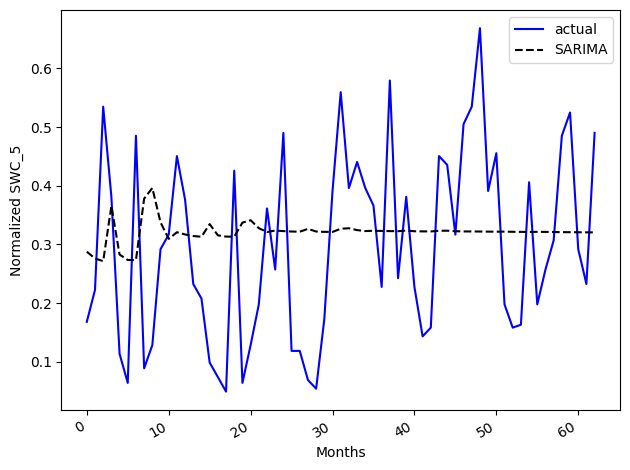

In [78]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total)
ax.plot(df_test, 'b-', label='actual')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [79]:
# Calculate MSE
mse=np.mean((df_test-pred_df.SARIMA)**2)

# Calculate MAE
mae = mean_absolute_error(df_test, pred_df.SARIMA)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(df_test, pred_df.SARIMA))

# Calculate MAPE
mape = np.mean(np.abs((df_test - pred_df.SARIMA) / df_test)) * 100

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MSE: 0.0254
MAE: 0.1421
RMSE: 0.1640
MAPE: 81.1934%
